In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/programmer3/construction-project-resource-dataset/Construction_Dataset.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv(
    '/kaggle/input/datasets/programmer3/construction-project-resource-dataset/Construction_Dataset.csv')

df.head()

,Labor Requirements,Equipment Usage,Material Quantities,Project Duration (days),Resource Allocation Efficiency,Schedule Optimization,Computation Time (CT),Best Cost (BC),Evaluation Metric (Nfe),Mean Resource Demand,SD of Resource Demand,Risk Level
0,152,21,752.666578,291,79.740040,0,119.105430,9.001976e+05,180,78.028242,10.530459,0
1,142,17,1463.863953,348,71.332190,1,153.138143,1.056578e+06,182,90.144405,15.429264,2
2,64,20,1639.016492,341,91.470780,0,101.541888,3.083878e+05,290,98.225578,12.600627,0
3,156,12,1250.667964,278,75.897926,1,233.622856,5.412628e+05,295,90.883581,15.876901,2
4,121,23,1313.545497,318,80.544442,0,125.276613,1.142576e+06,207,93.694853,12.613284,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Labor Requirements              1000 non-null   int64  
 1   Equipment Usage                 1000 non-null   int64  
 2   Material Quantities             1000 non-null   float64
 3   Project Duration (days)         1000 non-null   int64  
 4   Resource Allocation Efficiency  1000 non-null   float64
 5   Schedule Optimization           1000 non-null   int64  
 6   Computation Time (CT)           1000 non-null   float64
 7   Best Cost (BC)                  1000 non-null   float64
 8   Evaluation Metric (Nfe)         1000 non-null   int64  
 9   Mean Resource Demand            1000 non-null   float64
 10  SD of Resource Demand           1000 non-null   float64
 11  Risk Level                      1000 non-null   int64  
dtypes: float64(6), int64(6)
memory usag

In [6]:
df.describe()

,Labor Requirements,Equipment Usage,Material Quantities,Project Duration (days),Resource Allocation Efficiency,Schedule Optimization,Computation Time (CT),Best Cost (BC),Evaluation Metric (Nfe),Mean Resource Demand,SD of Resource Demand,Risk Level
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,125.846000,16.93300,1238.973329,295.273000,80.144450,0.477000,249.174062,6.460788e+05,223.565000,80.626932,15.004089,1.034000
std,43.786911,7.22362,430.883322,116.402199,11.402828,0.499721,85.723183,3.212678e+05,42.451053,11.686349,2.861113,0.815788
min,50.000000,5.00000,500.282599,100.000000,60.053851,0.000000,100.493127,1.006903e+05,150.000000,60.063177,10.013555,0.000000
25%,88.000000,11.00000,850.743683,193.000000,70.363962,0.000000,176.387896,3.618518e+05,187.000000,70.809250,12.593704,0.000000
50%,126.500000,17.00000,1242.449926,289.500000,80.478467,0.000000,249.812092,6.501784e+05,222.000000,80.936681,15.108641,1.000000
75%,164.000000,23.00000,1618.814497,400.250000,90.150673,1.000000,323.514467,9.082359e+05,259.000000,90.910337,17.528110,2.000000
max,199.000000,29.00000,1999.570706,498.000000,99.904913,1.000000,399.714849,1.199834e+06,299.000000,99.989651,19.994964,2.000000


In [8]:
df.isnull().sum()

Labor Requirements                0
Equipment Usage                   0
Material Quantities               0
Project Duration (days)           0
Resource Allocation Efficiency    0
Schedule Optimization             0
Computation Time (CT)             0
Best Cost (BC)                    0
Evaluation Metric (Nfe)           0
Mean Resource Demand              0
SD of Resource Demand             0
Risk Level                        0
dtype: int64

In [15]:
df.nunique()


Labor Requirements                 150
Equipment Usage                     25
Material Quantities               1000
Project Duration (days)            366
Resource Allocation Efficiency    1000
Schedule Optimization                2
Computation Time (CT)             1000
Best Cost (BC)                    1000
Evaluation Metric (Nfe)            150
Mean Resource Demand              1000
SD of Resource Demand             1000
Risk Level                           3
dtype: int64

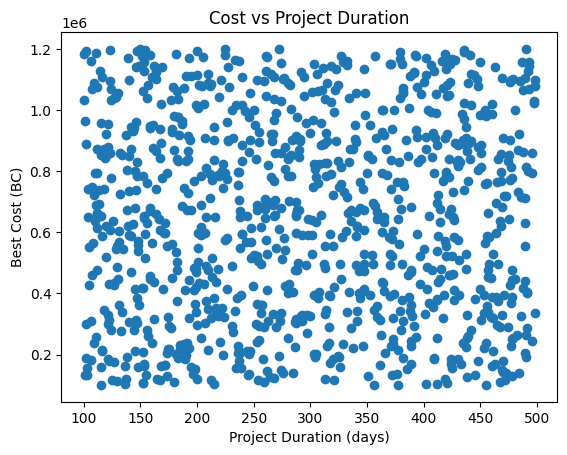

In [18]:
# معامل الارتباط (بيرسون)
df[['Best Cost (BC)', 'Project Duration (days)']].corr()

import matplotlib.pyplot as plt
plt.scatter(df['Project Duration (days)'], df['Best Cost (BC)'])
plt.xlabel('Project Duration (days)')
plt.ylabel('Best Cost (BC)')
plt.title('Cost vs Project Duration')
plt.show()

In [19]:
df.groupby('Risk Level')['Best Cost (BC)'].mean()

df['Risk Level'].value_counts()

df.groupby('Risk Level')['Best Cost (BC)'].describe()

,count,mean,std,min,25%,50%,75%,max
Risk Level,,,,,,,,
0,316.0,632597.070121,332171.861644,102555.746745,335600.898875,618724.804674,906683.396752,1.199834e+06
1,334.0,639484.418703,315107.557669,100690.268291,361254.988955,652313.563458,899312.906237,1.195181e+06
2,350.0,664543.889043,317121.198572,101761.306304,395543.735089,673069.069029,918698.485856,1.198151e+06


In [20]:
df_sorted = df.sort_values(by='Best Cost (BC)', ascending=True)
df_sorted[['Best Cost (BC)', 'Risk Level']].head(10)

,Best Cost (BC),Risk Level
390,100690.268291,1
258,100822.479208,1
569,101394.884607,1
926,101761.306304,2
562,102402.557143,1
67,102555.746745,0
138,104072.647516,0
600,104355.937313,0
296,105355.248421,0
114,107524.822963,2


In [21]:
df_sorted_desc = df.sort_values(by='Best Cost (BC)', ascending=False)
df_sorted_desc[['Best Cost (BC)', 'Risk Level']].head(10)

,Best Cost (BC),Risk Level
561,1.199834e+06,0
814,1.199415e+06,0
718,1.199270e+06,0
10,1.198151e+06,2
316,1.197775e+06,0
304,1.195593e+06,0
526,1.195181e+06,1
13,1.194252e+06,2
517,1.192936e+06,1
662,1.191888e+06,2


In [22]:
def cost_category(cost):
    if cost < df['Best Cost (BC)'].quantile(0.33):
        return 'Low'
    elif cost < df['Best Cost (BC)'].quantile(0.67):
        return 'Medium'
    else:
        return 'High'

df['Cost Category'] = df['Best Cost (BC)'].apply(cost_category)

df[['Best Cost (BC)', 'Cost Category']].head(10)

,Best Cost (BC),Cost Category
0,9.001976e+05,High
1,1.056578e+06,High
2,3.083878e+05,Low
3,5.412628e+05,Medium
4,1.142576e+06,High
5,5.362496e+05,Medium
6,2.373571e+05,Low
7,6.779896e+05,Medium
8,2.204401e+05,Low
9,3.231386e+05,Low


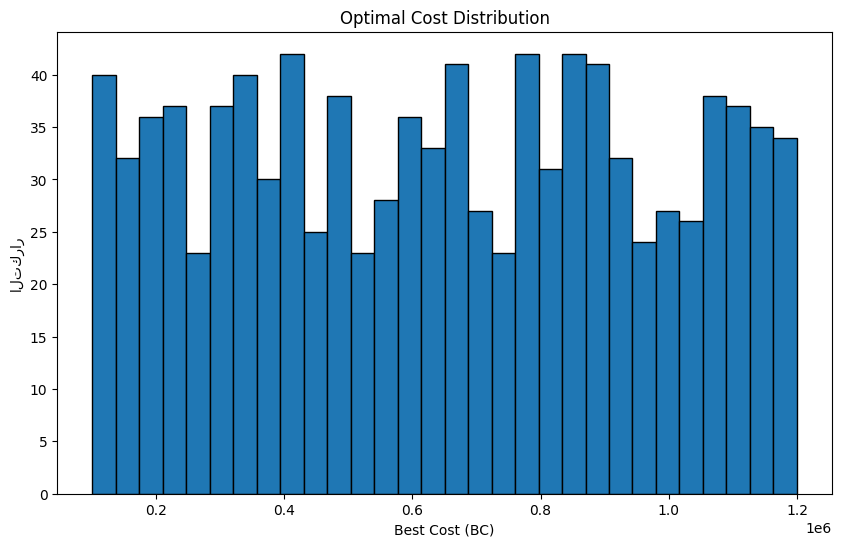

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
plt.hist(df['Best Cost (BC)'], bins=30, edgecolor='black')
plt.xlabel('Best Cost (BC)')
plt.ylabel('التكرار')
plt.title('Optimal Cost Distribution')
plt.show()

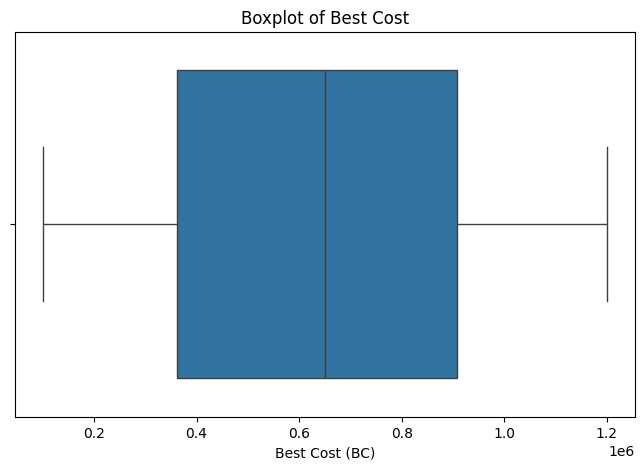

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Best Cost (BC)'])
plt.title('Boxplot of Best Cost')
plt.show()

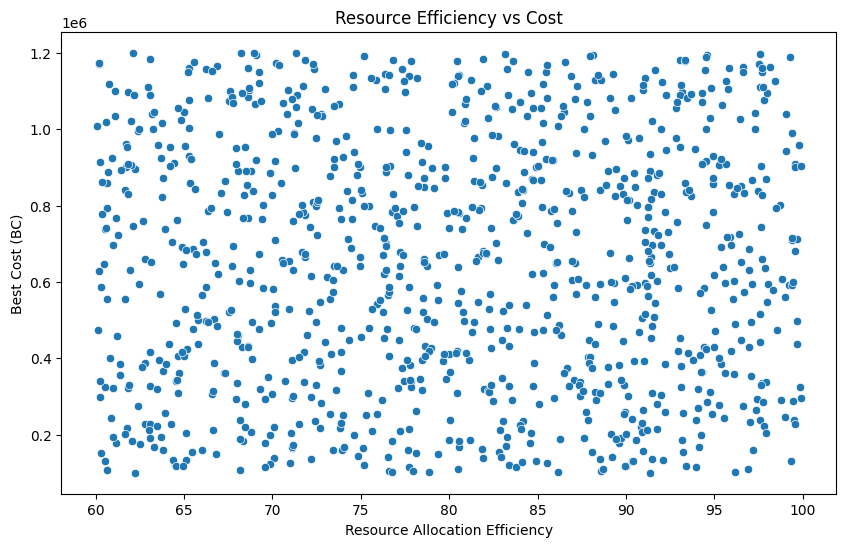

In [27]:
# هل Resource Allocation Efficiency بيأثر على Best Cost؟
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Resource Allocation Efficiency'], y=df['Best Cost (BC)'])
plt.xlabel('Resource Allocation Efficiency')
plt.ylabel('Best Cost (BC)')
plt.title('Resource Efficiency vs Cost')
plt.show()

In [29]:
correlation = df['Resource Allocation Efficiency'].corr(df['Best Cost (BC)'])
print(f"Correlation Coefficient = {correlation:.4f}")

Correlation Coefficient = 0.0088


In [30]:
cols_of_interest = ['Best Cost (BC)', 'Project Duration (days)', 
                    'Resource Allocation Efficiency', 'Labor Requirements', 
                    'Risk Level']

corr_matrix = df[cols_of_interest].corr()
print(corr_matrix)

                                Best Cost (BC)  Project Duration (days)  \
Best Cost (BC)                        1.000000                 0.020632   
Project Duration (days)               0.020632                 1.000000   
Resource Allocation Efficiency        0.008783                 0.042610   
Labor Requirements                    0.018465                -0.029115   
Risk Level                            0.040955                 0.021659   

                                Resource Allocation Efficiency  \
Best Cost (BC)                                        0.008783   
Project Duration (days)                               0.042610   
Resource Allocation Efficiency                        1.000000   
Labor Requirements                                   -0.005866   
Risk Level                                           -0.021299   

                                Labor Requirements  Risk Level  
Best Cost (BC)                            0.018465    0.040955  
Project Duration (days

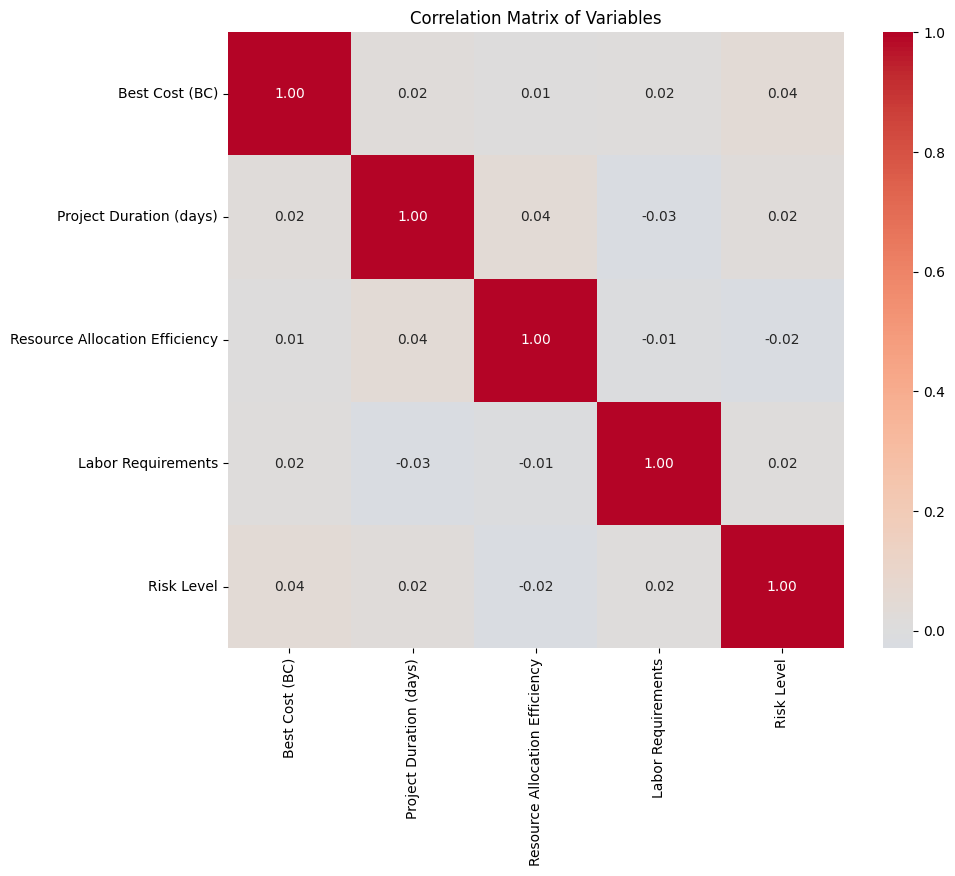

In [31]:
# رسم heatmap للارتباطات
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True)
plt.title('Correlation Matrix of Variables')
plt.show()

In [32]:
df.groupby('Risk Level')['Best Cost (BC)'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
Risk Level,,,,,
0,632597.070121,618724.804674,332171.861644,102555.746745,1.199834e+06
1,639484.418703,652313.563458,315107.557669,100690.268291,1.195181e+06
2,664543.889043,673069.069029,317121.198572,101761.306304,1.198151e+06


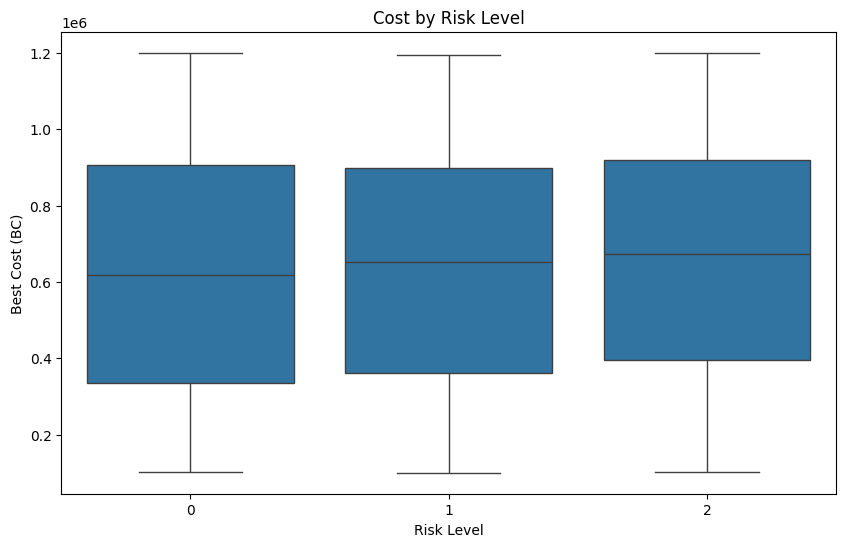

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Risk Level', y='Best Cost (BC)', data=df)
plt.title('Cost by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Best Cost (BC)')
plt.show()

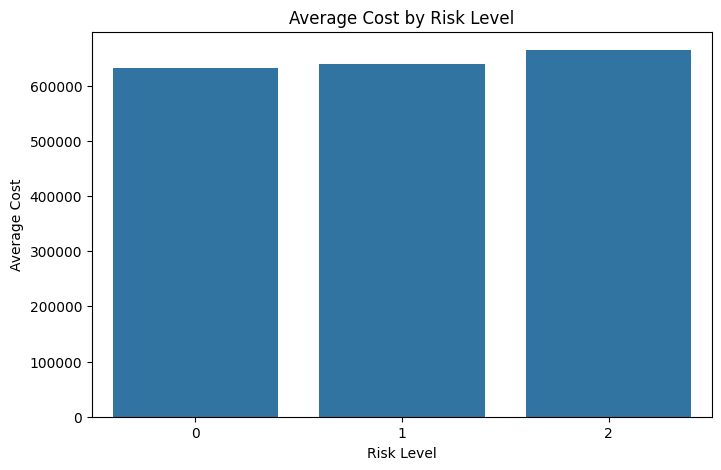

In [36]:
# رسم bar plot لمتوسط التكلفة لكل فئة مخاطرة
avg_cost_by_risk = df.groupby('Risk Level')['Best Cost (BC)'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Risk Level', y='Best Cost (BC)', data=avg_cost_by_risk)
plt.xlabel('Risk Level')
plt.ylabel('Average Cost')
plt.title('Average Cost by Risk Level')
plt.show()


In [37]:
df['Risk Category'] = df['Risk Level'].map({1: 'Low', 2: 'Medium', 3: 'High'})

df.groupby('Risk Category')['Project Duration (days)'].mean()

Risk Category
Low       307.643713
Medium    292.305714
Name: Project Duration (days), dtype: float64

In [40]:
df.groupby('Risk Category')['Project Duration (days)'].agg(['mean', 'median', 'std'])

,mean,median,std
Risk Category,,,
Low,307.643713,312.5,114.421703
Medium,292.305714,280.0,115.873539


In [39]:

df['Material Group'] = pd.qcut(df['Material Quantities'], q=3, 
                                labels=['Low Material', 'Medium Material', 'High Material'])

df.groupby('Material Group', observed=False)['Best Cost (BC)'].mean()

Material Group
Low Material       671388.456201
Medium Material    614197.186831
High Material      652574.845599
Name: Best Cost (BC), dtype: float64

In [42]:
df.groupby('Material Group', observed=False)['Resource Allocation Efficiency'].mean()

Material Group
Low Material       80.185436
Medium Material    78.988520
High Material      81.259271
Name: Resource Allocation Efficiency, dtype: float64

In [43]:
df.groupby('Risk Category')['Best Cost (BC)'].mean()

Risk Category
Low       639484.418703
Medium    664543.889043
Name: Best Cost (BC), dtype: float64

In [44]:
pd.crosstab(df['Material Group'], df['Risk Category'], 
            values=df['Best Cost (BC)'], aggfunc='mean')

Risk Category,Low,Medium
Material Group,,
Low Material,663451.023791,677042.688974
Medium Material,596122.819638,625166.088354
High Material,653154.464134,694797.042074
